In [1]:
import pyspark

In [2]:
pyspark.__file__

'/Users/iseohui/anaconda3/lib/python3.10/site-packages/pyspark/__init__.py'

In [3]:
from pyspark.sql import SparkSession

In [4]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")


26/03/09 21:57:06 WARN Utils: Your hostname, iseohuiui-MacBookAir.local resolves to a loopback address: 127.0.0.1; using 192.168.219.105 instead (on interface en0)
26/03/09 21:57:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 21:57:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.1


In [17]:
!wget https://github.com/DataTalksClub/nyc-tlc-data/releases/download/fhvhv/fhvhv_tripdata_2021-01.csv.gz

--2026-02-27 23:45:04--  https://github.com/DataTalksClub/nyc-tlc-data/releases/download/fhvhv/fhvhv_tripdata_2021-01.csv.gz
github.com (github.com) 해석 중... 20.200.245.247
다음으로 연결 중: github.com (github.com)|20.200.245.247|:443... 연결했습니다.
HTTP 요청을 보냈습니다. 응답 기다리는 중... 302 Found
위치: https://release-assets.githubusercontent.com/github-production-release-asset/513814948/035746e8-4e24-47e8-a3ce-edcf6d1b11c7?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-27T15%3A18%3A47Z&rscd=attachment%3B+filename%3Dfhvhv_tripdata_2021-01.csv.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-27T14%3A18%3A30Z&ske=2026-02-27T15%3A18%3A47Z&sks=b&skv=2018-11-09&sig=FI0kobLNII%2FbrmSg0HLb4PWnlbk%2BFHD8jZ7%2Bp45m%2FGg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MjIwNzEwNCwibmJmIjoxNzcyMjAzNTA0LCJwYXRoIjoicmVsZWFzZWFzc2V0

In [12]:
df = spark.read \
    .option("header", "true") \
    .csv('fhvhv_tripdata_2021-01.csv')

In [13]:
df.schema

StructType([StructField('hvfhs_license_num', StringType(), True), StructField('dispatching_base_num', StringType(), True), StructField('pickup_datetime', StringType(), True), StructField('dropoff_datetime', StringType(), True), StructField('PULocationID', StringType(), True), StructField('DOLocationID', StringType(), True), StructField('SR_Flag', StringType(), True)])

In [14]:
!head -n 1001 fhvhv_tripdata_2021-01.csv > head.csv

In [6]:
import pandas as pd


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/iseohui/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/iseohui/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/iseohui/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/iseohui/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/iseohui/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/iseohui/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/iseohui/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/iseohui/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  

AttributeError: _ARRAY_API not found

In [8]:
df_pandas = pd.read_csv('head.csv')

In [9]:
df_pandas.dtypes

hvfhs_license_num        object
dispatching_base_num     object
pickup_datetime          object
dropoff_datetime         object
PULocationID              int64
DOLocationID              int64
SR_Flag                 float64
dtype: object

In [10]:
spark.createDataFrame(df_pandas).schema

StructType([StructField('hvfhs_license_num', StringType(), True), StructField('dispatching_base_num', StringType(), True), StructField('pickup_datetime', StringType(), True), StructField('dropoff_datetime', StringType(), True), StructField('PULocationID', LongType(), True), StructField('DOLocationID', LongType(), True), StructField('SR_Flag', DoubleType(), True)])

- Integer - 4 bytes
- Long - 8 bytes

In [21]:
from pyspark.sql import types

In [22]:
schema = types.StructType([
    types.StructField('hvfhs_license_num', types.StringType(), True),
    types.StructField('dispatching_base_num', types.StringType(), True),
    types.StructField('pickup_datetime', types.TimestampType(), True),
    types.StructField('dropoff_datetime', types.TimestampType(), True),
    types.StructField('PULocationID', types.IntegerType(), True),
    types.StructField('DOLocationID', types.IntegerType(), True),
    types.StructField('SR_Flag', types.StringType(), True)
])

In [23]:
df = spark.read \
    .option("header", "true") \
    .schema(schema) \
    .csv('fhvhv_tripdata_2021-01.csv')

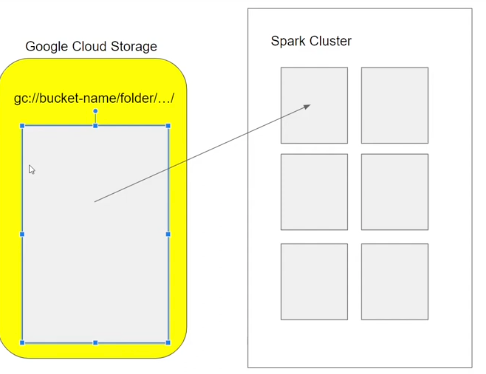
- 파일이 하나일 경우 하나의 executor를 제외한 다른 executor는 일하지 않음

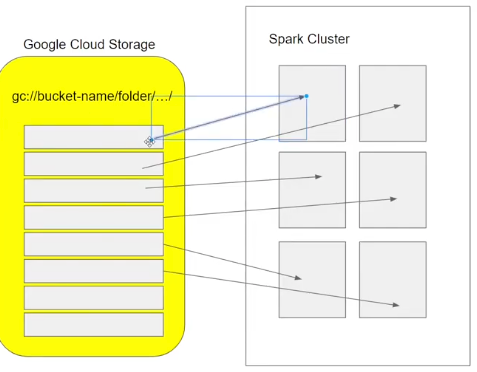
- 여러개의 파일로 나눔으로써 여러 executor가 일할 수 있도록 함

In [26]:
 df = df.repartition(24)

In [27]:
df.write.parquet('fhvhv/2021/01/')

26/02/28 00:28:16 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/02/28 00:28:18 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/02/28 00:28:19 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/02/28 00:28:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


In [11]:
df = spark.read.parquet('fhvhv/2021/01/')

In [12]:
df.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- SR_Flag: string (nullable = true)



In [14]:
df.show(1)

+-----------------+--------------------+-------------------+-------------------+------------+------------+-------+
|hvfhs_license_num|dispatching_base_num|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|SR_Flag|
+-----------------+--------------------+-------------------+-------------------+------------+------------+-------+
|           HV0003|              B02887|2021-01-03 15:07:03|2021-01-03 15:20:02|         165|         257|   NULL|
+-----------------+--------------------+-------------------+-------------------+------------+------------+-------+
only showing top 1 row



In [22]:
from pyspark.sql import functions as F, types

In [23]:
def crazy_stuff(base_num):
    num = int(base_num[1:])
    if num % 7 == 0:
        return f's/{num:03x}'
    elif num % 3 == 0:
        return f'a/{num:03x}'
    else:
        return f'e/{num:03x}'

In [24]:
crazy_stuff_udf = F.udf(crazy_stuff, returnType=types.StringType())

In [25]:
df \
    .withColumn('pickup_date', F.to_date(df.pickup_datetime)) \
    .withColumn('dropoff_date', F.to_date(df.dropoff_datetime)) \
    .withColumn('base_id', crazy_stuff_udf(df.dispatching_base_num)) \
    .select('base_id', 'pickup_date', 'dropoff_date', 'PULocationID', 'DOLocationID') \
    .show()


+-------+-----------+------------+------------+------------+
|base_id|pickup_date|dropoff_date|PULocationID|DOLocationID|
+-------+-----------+------------+------------+------------+
|  e/b47| 2021-01-03|  2021-01-03|         165|         257|
|  e/b32| 2021-01-02|  2021-01-02|         108|          29|
|  e/b3b| 2021-01-05|  2021-01-05|          41|          42|
|  e/b3e| 2021-01-02|  2021-01-02|         126|         213|
|  e/b33| 2021-01-04|  2021-01-04|          42|         132|
|  e/95b| 2021-01-03|  2021-01-03|          37|         198|
|  e/9ce| 2021-01-05|  2021-01-05|         130|         121|
|  e/9ce| 2021-01-02|  2021-01-02|         114|          37|
|  e/9ce| 2021-01-02|  2021-01-02|         225|          25|
|  e/b32| 2021-01-01|  2021-01-01|          75|          75|
|  e/b47| 2021-01-01|  2021-01-01|         164|         246|
|  s/b44| 2021-01-01|  2021-01-01|         186|         233|
|  e/b33| 2021-01-01|  2021-01-01|         177|          39|
|  s/b36| 2021-01-02|  2